# Sentinel-1 Band Sources -- Live Validation

This notebook is a **manual** validation of the band-sources work (issue [#348](
https://github.com/sentinel-hub/titiler-openeo/issues/348), ADR
[`docs/adr/0002-band-sources.md`](../adr/0002-band-sources.md)) against a real,
running backend and real Sentinel-1 GRD data -- the same spirit as
`sar_backscatter_rgb.ipynb`, but checking the band-sources pipeline instead of
`sar_backscatter` itself.

It checks three things, in order:

1. **Discovery (increment 1).** The derived band names show up in
   `describe_collection("sentinel-1-grd")`'s `cube:dimensions`.
2. **Production (increment 2).** `vv_noise_lut`/`vh_noise_lut` are actually
   *readable* via `load_collection`, and -- the important check -- their values
   reproduce `sar_backscatter`'s own noise subtraction exactly, computed two
   completely independent ways from the same live scene.
3. **Cost, live.** Reproduces the increment-2 gate measurement (ADR 0002 S4,
   increment 2) -- decomposed (band-source reads) vs. fused (`sar_backscatter`)
   -- against a real backend and a real scene's real GCP count, rather than the
   synthetic scaled fixture the gate itself used.

**This notebook is meant to be reused, not just run once.** Increment 3 adds
`CalibrationBandReader` (five more bands per polarisation); the last section
below describes exactly how to extend the same checks to them once that lands
-- no new notebook needed.

**Requires:** a running local titiler-openeo backend configured against a real
STAC catalogue with credentials (see `.env.cdse`), and the `openeo` Python
client (`pip install openeo`) -- these notebooks run in their own environment,
`openeo` is not a project dependency.

## Import Required Libraries

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import openeo
import rasterio

## Connect to OpenEO Backend

Same pattern as the other notebooks in this folder.

In [2]:
# connection = openeo.connect(
#     url="https://openeo.ds.io"
# ).authenticate_oidc_authorization_code()

connection = openeo.connect(
    url="http://127.0.0.1:8082/"
).authenticate_oidc_authorization_code()

## 1. Check Discovery

`getdimensions` (`stacapi.py`) should advertise every band the registry
describes for `sentinel-1-grd` -- both the one increment 2 makes readable
(`*_noise_lut`) and the five increment 3 will make readable
(`*_sigma0_lut`/`*_beta0_lut`/`*_gamma0_lut`/`*_dn_lut`/
`*_ellipsoid_incidence_angle`), since discovery is allowed to advertise a band
before its reader exists (that is increment 1's whole point -- see ADR 0002
S2.1).

In [3]:
collection = connection.describe_collection("sentinel-1-grd")
spectral = next(
    dim for dim in collection["cube:dimensions"].values() if dim["type"] == "bands"
)
band_names = set(spectral["values"])
print(f"{len(band_names)} bands advertised:")
print(sorted(band_names))

readable_now = {"vv_noise_lut", "vh_noise_lut"}
discovery_only_for_now = {
    f"{pol}_{suffix}"
    for pol in ("vv", "vh")
    for suffix in (
        "sigma0_lut",
        "beta0_lut",
        "gamma0_lut",
        "dn_lut",
        "ellipsoid_incidence_angle",
    )
}
missing = (readable_now | discovery_only_for_now) - band_names
if missing:
    print(f"\nMISSING from discovery: {sorted(missing)}")
else:
    print(
        "\nAll expected derived band names (increment 2 + increment 3) are advertised."
    )

28 bands advertised:
['hh', 'hh_beta0_lut', 'hh_dn_lut', 'hh_ellipsoid_incidence_angle', 'hh_gamma0_lut', 'hh_noise_lut', 'hh_sigma0_lut', 'hv', 'hv_beta0_lut', 'hv_dn_lut', 'hv_ellipsoid_incidence_angle', 'hv_gamma0_lut', 'hv_noise_lut', 'hv_sigma0_lut', 'vh', 'vh_beta0_lut', 'vh_dn_lut', 'vh_ellipsoid_incidence_angle', 'vh_gamma0_lut', 'vh_noise_lut', 'vh_sigma0_lut', 'vv', 'vv_beta0_lut', 'vv_dn_lut', 'vv_ellipsoid_incidence_angle', 'vv_gamma0_lut', 'vv_noise_lut', 'vv_sigma0_lut']

All expected derived band names (increment 2 + increment 3) are advertised.


## 2. Load Sentinel-1 GRD

The AOI below is the same Tokyo Bay acquisition `sar_backscatter_rgb.ipynb`
uses: open water, dense urban/industrial structures, and hills inland, so
noise and backscatter aren't uniform across the scene -- worth having variety
when eyeballing plots later.

Same two traps as that notebook: `temporal_extent` must be ISO 8601 with the
`T`, and a narrow, sub-minute window is the reliable way to pin exactly one
acquisition (Sentinel-1 footprints are slanted parallelograms, so a wider
window risking >1 item defeats the pixel-for-pixel comparison below --
`sar_backscatter` itself refuses to calibrate a mosaicked, >1-item slice, and
band sources currently don't get exercised against that case here either).

`GRID_SIZE` is fixed and reused for every request in this notebook -- the
cross-check in section 3 only means something if every cube lands on the
*identical* destination grid.

In [4]:
# Tokyo Bay AOI (same acquisition as sar_backscatter_rgb.ipynb)
spatial_extent = {"west": 139.5, "south": 35.2, "east": 140.2, "north": 35.8}
temporal_extent = [
    "2026-07-08T20:42:55Z",
    "2026-07-08T20:43:20Z",
]  # adjust to a real S1 pass over the AOI

GRID_SIZE = 512
POLARISATIONS = ["vv", "vh"]

## 3. Load Two Cubes on the Same Grid, Cross-Validate

Two `load_collection` calls, identical in every parameter except `bands`:

* **`dn_plus_derived`** -- the DN bands plus every derived band this registry
  describes (`<pol>_noise_lut` and, as of increment 3, the four calibration
  LUTs plus the incidence angle), read through the band-sources path this
  notebook is validating.
* **`fused_null`** -- the DN bands alone, then `sar_backscatter(coefficient=
  None, noise_removal=True)`. `coefficient=None` is openEO's `null` --
  `sar_backscatter` returns `DN^2` uncalibrated, minus the noise LUT it
  evaluates *internally*, clamped at 0 (`calibration.py:51-59`). This is the
  same `power` calibration.py divides by `A^2` for every coefficient, so it
  backs both the noise check right below and the calibration check in
  section 3b.

If `vv_noise_lut`/`vh_noise_lut` are correct, `max(DN^2 - noise_lut, 0)`
computed by hand from the first cube's bands must equal the second cube's
output exactly -- two independent computations (one server-side inside
`sar_backscatter`, one by hand in this notebook from bands read a completely
different way) landing on the same numbers is a much stronger check than
either alone.

`width=`/`height=` are backend-specific `load_collection` parameters (not
part of the openEO spec), so they go through `datacube_from_process` rather
than the client's `.load_collection()` convenience wrapper -- the same
pattern `evi.ipynb` uses for `width=None`.

**Ordering matters here, the same way it does in `sar_backscatter_rgb.ipynb`.**
`sar_backscatter` needs `get_source_items` on its input, which only survives
through `RasterStack.map_tasks` -- `reduce_dimension` (like `merge_cubes`,
`ndvi`, `apply`, ...) ends in `RasterStack.from_images` and drops it. So
`sar_backscatter` must run on `load_collection`'s *direct* output, and
`reduce_dimension` (needed to flatten to one image for `.download()`) comes
strictly after it, never before -- `load_s1` below deliberately returns the
unflattened cube so each caller controls that ordering itself.

In [5]:
def load_s1(bands, width=GRID_SIZE, height=GRID_SIZE):
    """Load, unflattened -- callers decide where reduce_dimension goes."""
    return connection.datacube_from_process(
        "load_collection",
        id="sentinel-1-grd",
        spatial_extent=spatial_extent,
        temporal_extent=temporal_extent,
        bands=bands,
        width=width,
        height=height,
    )


def flatten(cube):
    return cube.reduce_dimension(dimension="t", reducer="firstpixel")


noise_lut_bands = [f"{pol}_noise_lut" for pol in POLARISATIONS]
# Increment 3: the four calibration LUT vectors plus the incidence angle,
# per polarisation -- discoverable since increment 1, readable since
# increment 3 (CalibrationBandReader).
calibration_suffixes = ["sigma0_lut", "beta0_lut", "gamma0_lut", "dn_lut"]
calibration_lut_bands = [
    f"{pol}_{suffix}" for pol in POLARISATIONS for suffix in calibration_suffixes
]
incidence_angle_bands = [f"{pol}_ellipsoid_incidence_angle" for pol in POLARISATIONS]

# Band order in dn_plus_derived is exactly this list's order (guaranteed by
# request order -- see section 3's note on rasterio.descriptions being
# unavailable). Every cell below indexes into it by name via band(), not by
# position, so it stays correct if this list is reordered or extended.
derived_band_list = (
    POLARISATIONS + noise_lut_bands + calibration_lut_bands + incidence_angle_bands
)

dn_plus_derived = flatten(load_s1(derived_band_list))
dn_plus_derived.download("band_sources_dn_plus_noise.tif", format="GTiff")

fused_null = load_s1(POLARISATIONS)
fused_null = fused_null.process(
    "sar_backscatter", data=fused_null, coefficient=None, noise_removal=True
)
fused_null = flatten(fused_null)
fused_null.download("band_sources_fused_null.tif", format="GTiff")

with rasterio.open("band_sources_dn_plus_noise.tif") as src:
    print(f"dn_plus_derived: {src.count} bands, shape {src.shape}")
with rasterio.open("band_sources_fused_null.tif") as src:
    print(f"fused_null:      {src.count} bands, shape {src.shape}")

dn_plus_derived: 14 bands, shape (512, 512)
fused_null:      2 bands, shape (512, 512)


In [6]:
with rasterio.open("band_sources_dn_plus_noise.tif") as src:
    derived = src.read(masked=True).astype("float64")
with rasterio.open("band_sources_fused_null.tif") as src:
    fused_power = src.read(masked=True).astype("float64")


def band(name):
    """derived[...] by name -- band order is request order, not something
    rasterio.descriptions can confirm on this backend (see section 3)."""
    return derived[derived_band_list.index(name)]


for i, pol in enumerate(POLARISATIONS):
    manual = np.ma.maximum(band(pol) ** 2 - band(f"{pol}_noise_lut"), 0.0)
    valid = ~(manual.mask | fused_power[i].mask)
    diff = np.abs(manual.filled(0) - fused_power[i].filled(0))[valid]
    if diff.size == 0:
        print(f"{pol}: no overlapping valid pixels -- widen the AOI/time window")
        continue
    match = np.allclose(
        manual.filled(0)[valid], fused_power[i].filled(0)[valid], rtol=1e-4, atol=1e-3
    )
    print(
        f"{pol}: max abs diff = {diff.max():.6g}, mean = {diff.mean():.6g}, "
        f"{valid.sum()}px compared -- "
        f"{'MATCH' if match else 'MISMATCH -- investigate before trusting the pipeline'}"
    )

vv: max abs diff = 11.2678, mean = 0.00382318, 262115px compared -- MATCH
vh: max abs diff = 0.941833, mean = 0.000563802, 262115px compared -- MATCH


## 3b. Calibration LUT and Incidence Angle (increment 3)

Same idea as section 3, applied to `CalibrationBandReader`. `sar_backscatter`
computes `coefficient / A^2` internally (`calibration.py`'s `power / a**2`,
`power` from `fused_power` above), so `vv_sigma0_lut` reproducing
`sar_backscatter(coefficient="sigma0-ellipsoid")` when combined with that
same `power` is the same two-independent-computations check as section 3,
just one coefficient deeper.

`ellipsoid_incidence_angle` has its own oracle, independent of DN entirely:
`sar_backscatter(..., ellipsoid_incidence_angle=True)` appends a band that
must equal `<pol>_ellipsoid_incidence_angle` read directly -- no arithmetic,
just a direct pixel comparison. Piggy-backed onto the same download below
(it doesn't depend on `coefficient`, so no second download is needed).

`beta0`/`gamma0-ellipsoid` follow the identical pattern against
`vv_beta0_lut`/`vv_gamma0_lut` -- see the status note at the end of this
notebook for why they aren't repeated here.

In [7]:
fused_sigma0 = load_s1(POLARISATIONS)
fused_sigma0 = fused_sigma0.process(
    "sar_backscatter",
    data=fused_sigma0,
    coefficient="sigma0-ellipsoid",
    noise_removal=True,
    ellipsoid_incidence_angle=True,
)
fused_sigma0 = flatten(fused_sigma0)
fused_sigma0.download("band_sources_fused_sigma0.tif", format="GTiff")

with rasterio.open("band_sources_fused_sigma0.tif") as src:
    fused_sigma0_data = src.read(masked=True).astype("float64")

print("--- coefficient='sigma0-ellipsoid' ---")
for i, pol in enumerate(POLARISATIONS):
    lut = band(f"{pol}_sigma0_lut")
    manual = np.ma.masked_invalid(fused_power[i] / lut**2)
    valid = ~(manual.mask | fused_sigma0_data[i].mask)
    diff = np.abs(manual.filled(0) - fused_sigma0_data[i].filled(0))[valid]
    if diff.size == 0:
        print(f"  {pol}: no overlapping valid pixels")
        continue
    match = np.allclose(
        manual.filled(0)[valid],
        fused_sigma0_data[i].filled(0)[valid],
        rtol=1e-4,
        atol=1e-3,
    )
    print(
        f"  {pol}: max abs diff = {diff.max():.6g}, mean = {diff.mean():.6g} -- "
        f"{'MATCH' if match else 'MISMATCH'}"
    )

print("\n--- ellipsoid_incidence_angle ---")
incidence_fused = fused_sigma0_data[len(POLARISATIONS)]  # appended after DN bands
for pol in POLARISATIONS:
    direct = band(f"{pol}_ellipsoid_incidence_angle")
    valid = ~(direct.mask | incidence_fused.mask)
    diff = np.abs(direct.filled(0) - incidence_fused.filled(0))[valid]
    if diff.size == 0:
        print(f"  {pol}: no overlapping valid pixels")
        continue
    match = np.allclose(
        direct.filled(0)[valid], incidence_fused.filled(0)[valid], atol=0.01
    )
    print(
        f"  {pol}: max abs diff = {diff.max():.4g} deg -- {'MATCH' if match else 'MISMATCH'}"
    )

--- coefficient='sigma0-ellipsoid' ---
  vv: max abs diff = 0.000122302, mean = 2.38423e-08 -- MATCH
  vh: max abs diff = 3.70928e-06, mean = 3.39246e-09 -- MATCH

--- ellipsoid_incidence_angle ---
  vv: max abs diff = 0 deg -- MATCH
  vh: max abs diff = 0 deg -- MATCH


## 4. Visual Sanity Check

The noise LUT should look like a smooth, low-frequency field (ESA's LUTs are
sampled every ~1500 pixels in range and vary smoothly -- ADR
[0001](../adr/0001-sar-backscatter.md) S1.6d) -- not noisy, not blocky, and
not a constant (a flat image at this stage usually means the destination grid
missed the item's real footprint -- see `sar_backscatter_rgb.ipynb`'s note on
slanted parallelograms and the `mask` band).

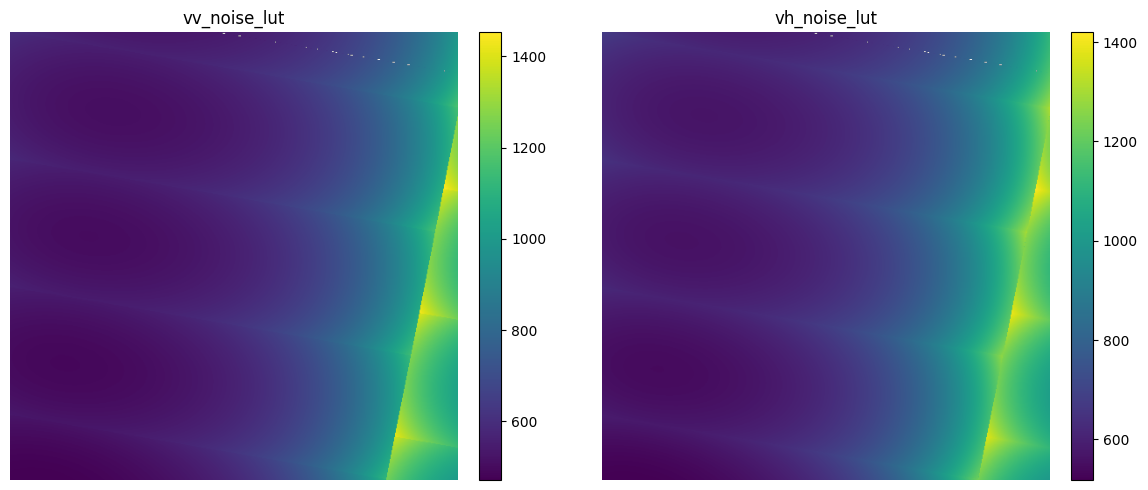

In [8]:
fig, axes = plt.subplots(1, len(POLARISATIONS), figsize=(6 * len(POLARISATIONS), 5))
if len(POLARISATIONS) == 1:
    axes = [axes]
for ax, pol in zip(axes, POLARISATIONS):
    im = ax.imshow(band(f"{pol}_noise_lut"), cmap="viridis")
    ax.set_title(f"{pol}_noise_lut")
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 5. Live Cost Check: Decomposed vs. Fused

Reproduces the increment-2 gate (ADR 0002 S4) against this backend's real
scene instead of the synthetic 440-GCP polar fixture the gate script used
locally.

**Read this number correctly.** The comparison that matters is *decomposed
vs. fused*, not *with-LUT vs. without*: both `dn_plus_derived` and
`fused_null` pay the same TPS inverse-map fit (`geocode.build_inverse_map`)
exactly once each. An early version of the local gate measurement compared
against a bare DN-only read and found a 33x-233x blowup -- that comparison
was wrong, and measured the cost of wanting a LUT at all, not the cost of
decomposition. What this cell checks is whether **reading the LUT as a
separate band costs more than `sar_backscatter` already costs today** -- the
local measurement said no (1.00x at both 256^2 and 1024^2). This is that same
check, live.

Expect the *ratio* to land near 1.0 regardless of network/server overhead
(both requests pay it), even though the *absolute* seconds here will differ
from the local synthetic-fixture numbers -- this scene's real GCP count
almost certainly differs from the fixture's 440.

In [11]:
SIZES = [256, 512, 1024]
results = []

for size in SIZES:
    decomposed = flatten(
        load_s1(POLARISATIONS + noise_lut_bands, width=size, height=size)
    )

    fused = load_s1(POLARISATIONS, width=size, height=size)
    fused = fused.process(
        "sar_backscatter", data=fused, coefficient=None, noise_removal=True
    )
    fused = flatten(fused)  # after sar_backscatter, same ordering constraint as above

    t0 = time.perf_counter()
    decomposed.download(f"_tmp_decomposed_{size}.tif", format="GTiff")
    t_decomposed = time.perf_counter() - t0

    t0 = time.perf_counter()
    fused.download(f"_tmp_fused_{size}.tif", format="GTiff")
    t_fused = time.perf_counter() - t0

    ratio = t_decomposed / t_fused if t_fused else float("nan")
    results.append((size, t_decomposed, t_fused, ratio))
    print(
        f"{size:>5}px  decomposed={t_decomposed:7.2f}s  fused={t_fused:7.2f}s  ratio={ratio:5.2f}"
    )

  256px  decomposed=   0.93s  fused=   1.24s  ratio= 0.74
  512px  decomposed=   2.46s  fused=   3.51s  ratio= 0.70
 1024px  decomposed=   8.37s  fused=  11.18s  ratio= 0.75


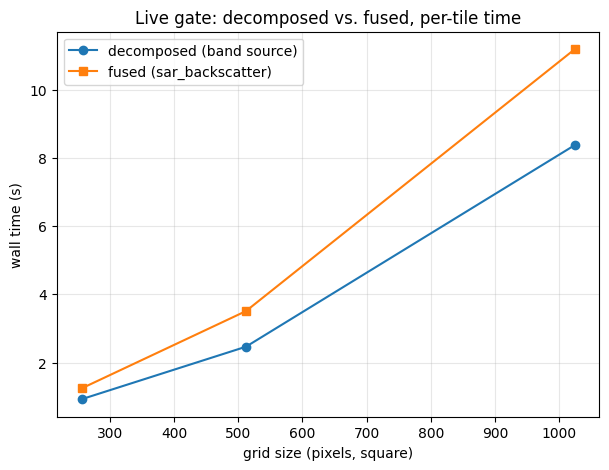

In [12]:
sizes, t_decomposed, t_fused, _ = zip(*results)
plt.figure(figsize=(7, 5))
plt.plot(sizes, t_decomposed, "o-", label="decomposed (band source)")
plt.plot(sizes, t_fused, "s-", label="fused (sar_backscatter)")
plt.xlabel("grid size (pixels, square)")
plt.ylabel("wall time (s)")
plt.title("Live gate: decomposed vs. fused, per-tile time")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Status

**Increment 3: done.** `CalibrationBandReader` backs
`<pol>_sigma0_lut`/`_beta0_lut`/`_gamma0_lut`/`_dn_lut`/
`_ellipsoid_incidence_angle`, cross-validated in section 3b the same way
section 3 cross-validates noise -- against `sar_backscatter`'s own output,
computed two independent ways. The duplication ADR 0002's risk log
anticipated (each calibration band rebuilding the same inverse map) turned
out to hit a real concurrency bug rather than just a timing one --
`RasterStack`'s thread pool let concurrent requests race past an unlocked
cache check, measured directly at 2 builds instead of 1 for five bands from
one asset (`tests/test_calibration_band_reader.py`) -- fixed with a lock, not
something this live notebook is set up to reproduce (it needs concurrent
requests hitting one item, which a single-cell sequential download won't
trigger).

**`beta0`/`gamma0-ellipsoid` aren't separately checked above** -- same
pattern as `sigma0-ellipsoid` against `vv_beta0_lut`/`vv_gamma0_lut`, left
out to keep this notebook focused. **`vv_dn_lut`/`vh_dn_lut` have no
arithmetic oracle**: no openEO `sar_backscatter` coefficient exposes the raw
DN-scale LUT directly (only `sigma0-ellipsoid`/`beta0`/`gamma0-ellipsoid` do,
via `A` in `calibration.py`'s `power / A**2`) -- loaded above for
discovery/visual inspection only.

No further extension is anticipated for this notebook: increments 4/5
(ADR 0002 S4) build the reader-requirement planner, and increment 6 converges
`sar_backscatter` onto these same bands internally. Neither changes what a
user requests via `load_collection`, so the checks above should keep passing
unchanged through both.